In [8]:
# %% SCRIPT TO RUN THE MODEL
# Import matplotlib to generate figures
import matplotlib.pyplot as plt
# This is an example script that runs
# the ecohydrology model.
from farm import Climate
from farm import Soil
from farm import Crop
from farm import CropModel

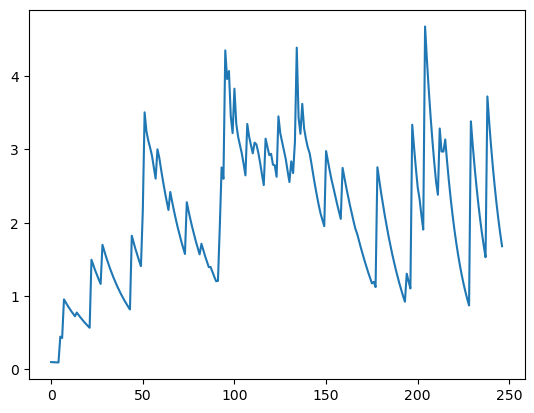

In [ ]:
# %% Initialize Climate
climate = Climate()

# %% Initialize Soil
soil = Soil(texture='loam')

# %% Initialize Plant
crop = Crop(soil=soil)

# Finally, now that the plant is defined, we need
# to set the soil.nZr property:
soil.set_nZr(crop)

# %% Initialize the Model
model = CropModel(crop=crop, climate=climate, soil=soil)

# %% Run the Model
model.run()

# %% Assign Model Output
output = model.output()

# %% Generate figures
output['ET'].plot()

plt.show()


In [11]:
def calc_yield(stress=None, max_yield = 4680):
    yield_kg_ha = -max_yield*stress + max_yield
    
    if stress > 1:
        raise ValueError("static stress, {stress} is larger than 1".format(
                stress=stress))
    if stress < 0:
        raise ValueError("static stress, {stress} is less than 0".format(
                stress=stress))
    
    return yield_kg_ha

Stress: 0.85
Yield: 720 kg/ha


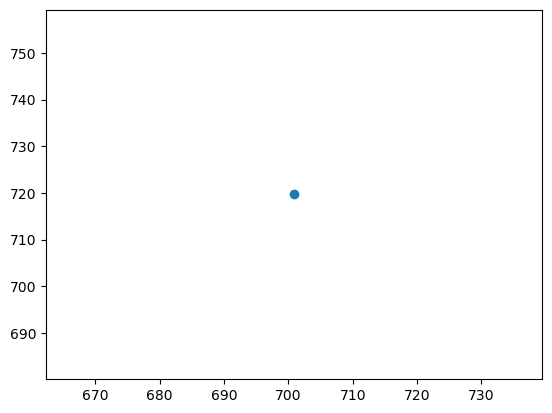

In [15]:
T_actual = output['T'].sum()
T_potential = output['kc'].max() * climate.ET_max * len(output)

stress = 1 - (T_actual / T_potential)
stress = max(0, min(1, stress))  

yield_kg_ha = calc_yield(stress)

print(f"Stress: {stress:.2f}")
print(f"Yield: {yield_kg_ha:.0f} kg/ha")

seasonal_rain = output['R'].sum()  # mm over the season
plt.scatter(seasonal_rain, yield_kg_ha)

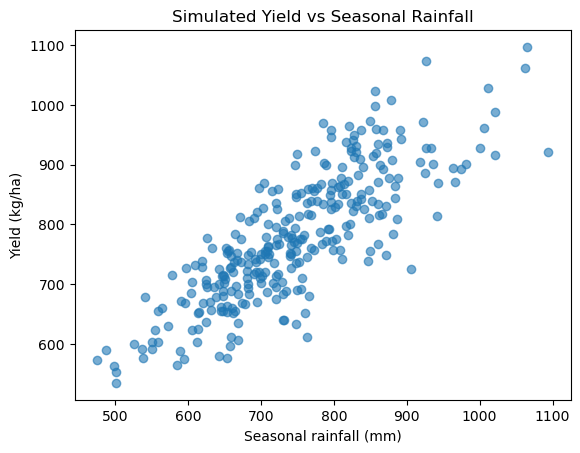

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from farm import Climate, Soil, Crop, CropModel

def calc_yield(stress, max_yield=4680):
    if not (0 <= stress <= 1):
        raise ValueError("stress must be in [0,1]")
    return max_yield * (1 - stress)

def run_one_season(seed=None, texture="loam",
                   alpha_r=10.0, lambda_r=0.3, t_seas=180, ET_max=6.5):
    if seed is not None:
        np.random.seed(seed)

    climate = Climate(alpha_r=alpha_r, lambda_r=lambda_r, t_seas=t_seas, ET_max=ET_max)
    soil = Soil(texture=texture)
    crop = Crop(soil=soil)
    soil.set_nZr(crop)

    model = CropModel(crop=crop, climate=climate, soil=soil)
    model.run()
    output = model.output()

    # Seasonal totals
    seasonal_rain = float(output["R"].sum())          # mm
    T_actual = float(output["T"].sum())               # mm

    T_potential = float(output["kc"].max() * climate.ET_max * len(output))

    stress = 1 - (T_actual / T_potential) if T_potential > 0 else 1.0
    stress = max(0.0, min(1.0, stress))

    y = float(calc_yield(stress))                     # kg/ha
    return seasonal_rain, y, stress

# Run
N = 300 
rows = []
for i in range(N):
    rain, yld, stress = run_one_season(seed=i)  
    rows.append({"seasonal_rain_mm": rain, "yield_kg_ha": yld, "stress": stress})

df = pd.DataFrame(rows)

# plot
plt.figure()
plt.scatter(df["seasonal_rain_mm"], df["yield_kg_ha"], alpha=0.6)
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Yield (kg/ha)")
plt.title("Simulated Yield vs Seasonal Rainfall")
plt.show()


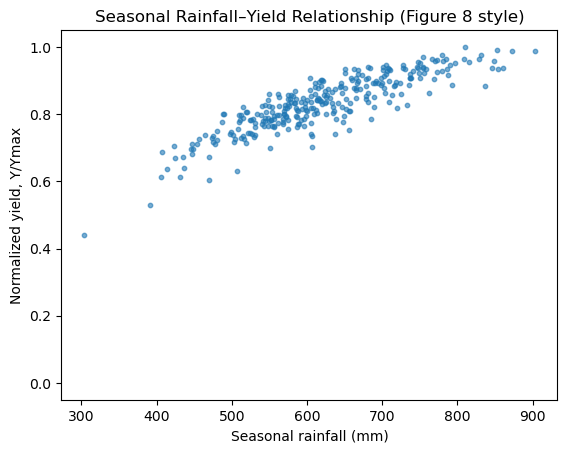

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evolved_calc_yield(dtm=120, m=None, b=None):
    # Simple fallback if you don't have the repo's regression loaded
    # Replace with the repo’s evolved_calc_yield if you want the exact calibration
    Y_MAX = 4680  # kg/ha
    return Y_MAX

def dynamic_stress_to_yield(output_df, Y_MAX):
    """
    Figure-8 style: use *dynamic* (time-varying) stress from the model output.
    Here we summarize it as the seasonal mean stress, then convert to yield.
    """
    dyn_stress = float(np.mean(output_df["stress"]))  # stress in [0,1]
    dyn_stress = max(0.0, min(1.0, dyn_stress))
    y = Y_MAX * (1 - dyn_stress)
    return dyn_stress, y

from farm import Climate, Soil, Crop, CropModel

N = 300
lgp = 120  # pick a days-to-maturity / length-of-growing-period you want
Y_MAX = evolved_calc_yield(dtm=lgp)

rows = []
for seed in range(N):
    np.random.seed(seed)  # reproducible stochastic rainfall

    climate = Climate()              # or set alpha_r/lambda_r/t_seas/ET_max
    soil = Soil(texture="loam")
    crop = Crop(soil=soil)
    soil.set_nZr(crop)

    model = CropModel(crop=crop, climate=climate, soil=soil)
    model.run()
    out = model.output()             # DataFrame with 'stress' and 'R'

    RF = float(out["R"].sum())       # seasonal rainfall (mm)
    dyn_stress, y = dynamic_stress_to_yield(out, Y_MAX)

    rows.append({"RF": RF, "Yield": y, "DynamicStress": dyn_stress})

df = pd.DataFrame(rows)
df["Yield_norm"] = df["Yield"] / df["Yield"].max()

plt.figure()
plt.scatter(df["RF"], df["Yield_norm"], alpha=0.6, s=10)
plt.ylim(-0.05, 1.05)
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Normalized yield, Y/Ymax")
plt.title("Seasonal Rainfall–Yield Relationship (Figure 8 style)")
plt.show()
